# Exploratory Data Analysis (EDA) - Pandas Repository
*Member:* Zaidan — Data Engineer
*Tujuan:* Mengekstrak data dari GitHub API, melakukan pembersihan awal, dan memvisualisasikan data untuk melihat pola distribusi Poisson (frekuensi issue) dan Bernoulli (status Pull Request).

## AI Usage Disclosure
| Task                          | Tool   | Prompt summary     
| Output modified?              |--------| --------------------------------------------------
| Membuat loop pagination API   | Gemini | "Buatkan script tarik data API GitHub Pandas..."  
| Membuat plot visualisasi EDA  | Gemini | "Buatkan bar chart dan histogram dengan seaborn"  | Tidak                   |
| Ya — disesuaikan folder |
*Written entirely without AI:* Interpretasi grafik Poisson, interpretasi grafik Bernoulli, dan kesimpulan akhir.

In [16]:
import datetime
import json
import os
import time
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- KONFIGURASI API ---
TOKEN = "TOKEN_ZAIDAN"  
REPO = "pandas-dev/pandas"
TARGET_COUNT = 2000

five_years_ago = datetime.datetime.now() - datetime.timedelta(days=5 * 365)
since_date = five_years_ago.strftime("%Y-%m-%dT%H:%M:%SZ")

headers = {
    "Authorization": f"token {TOKEN}",
    "Accept": "application/vnd.github.v3+json",
}

### 1. Ekstraksi Data dari GitHub API
Proses penarikan data secara rekursif menggunakan *pagination* untuk mengambil gabungan data *Issue* dan *Pull Request*.

In [10]:
all_issues = []
page = 1
per_page = 100 

print(f"Memulai pengambilan data dari {REPO} sejak: {since_date}")

while len(all_issues) < TARGET_COUNT:
    url = f"https://api.github.com/repos/{REPO}/issues"
    params = {
        "state": "all",
        "since": since_date,
        "per_page": per_page,
        "page": page,
        "sort": "created",
        "direction": "desc",
    }

    response = requests.get(url, headers=headers, params=params)

    if response.status_code != 200:
        print(f"Error: {response.status_code}")
        break

    data = response.json()
    if not data:
        break

    for item in data:
        is_pr = "pull_request" in item
        merged = False
        if is_pr and item.get("pull_request", {}).get("merged_at") is not None:
            merged = True
            
        all_issues.append({
            "id": item["id"],
            "number": item["number"],
            "title": item["title"],
            "state": item["state"],
            "created_at": item["created_at"],
            "closed_at": item.get("closed_at"),
            "is_pull_request": is_pr,
            "is_merged": merged,
            "author_association": item.get("author_association"),
        })

    print(f"Page {page} diproses. Total data: {len(all_issues)}")
    time.sleep(1) 
    page += 1

final_issues = all_issues[:TARGET_COUNT]
print(f"\nBerhasil mengambil {len(final_issues)} data gabungan.")

raw_folder = "../data/raw"
os.makedirs(raw_folder, exist_ok=True)
raw_file_path = os.path.join(raw_folder, "raw_pandas_data.json")

with open(raw_file_path, "w") as f:
    json.dump(final_issues, f)

print(f"SUKSES: Data asli (raw) berhasil dikunci di '{raw_file_path}'")

Memulai pengambilan data dari pandas-dev/pandas sejak: 2021-05-25T16:32:03Z
Page 1 diproses. Total data: 100
Page 2 diproses. Total data: 200
Page 3 diproses. Total data: 300
Page 4 diproses. Total data: 400
Page 5 diproses. Total data: 500
Page 6 diproses. Total data: 600
Page 7 diproses. Total data: 700
Page 8 diproses. Total data: 800
Page 9 diproses. Total data: 900
Page 10 diproses. Total data: 1000
Page 11 diproses. Total data: 1100
Page 12 diproses. Total data: 1200
Page 13 diproses. Total data: 1300
Page 14 diproses. Total data: 1400
Page 15 diproses. Total data: 1500
Page 16 diproses. Total data: 1600
Page 17 diproses. Total data: 1700
Page 18 diproses. Total data: 1800
Page 19 diproses. Total data: 1900
Page 20 diproses. Total data: 2000

Berhasil mengambil 2000 data gabungan.
SUKSES: Data asli (raw) berhasil dikunci di '../data/raw\raw_pandas_data.json'


### 2. Pembersihan dan Penyimpanan Data
Mengonversi list ke dalam Pandas DataFrame, merapikan format *datetime*, dan menyimpan data bersih ke folder `data/clean/`.

In [11]:
# Ambil data dari list final_issues yang tadi
df = pd.DataFrame(final_issues)

# Di sini proses modifikasi/cleaning baru boleh berjalan
df['created_at'] = pd.to_datetime(df['created_at'])
df['closed_at'] = pd.to_datetime(df['closed_at'])

# Cek nilai yang kosong
print("Pengecekan Missing Values di Data Clean:")
print(df.isnull().sum())

# Simpan ke data/clean
clean_folder = "../data/clean"
os.makedirs(clean_folder, exist_ok=True)
clean_file_path = os.path.join(clean_folder, "dataset.csv")

df.to_csv(clean_file_path, index=False)
print(f"\nSUKSES: Data bersih (clean) berhasil disimpan ke '{clean_file_path}'")

Pengecekan Missing Values di Data Clean:
id                      0
number                  0
title                   0
state                   0
created_at              0
closed_at             361
is_pull_request         0
is_merged               0
author_association      0
dtype: int64

SUKSES: Data bersih (clean) berhasil disimpan ke '../data/clean\dataset.csv'


### 3. Visualisasi untuk Distribusi Poisson (Frekuensi Issue per Hari)
Mengecek apakah frekuensi kemunculan *issue* dan PR per harinya membentuk pola distribusi Poisson.

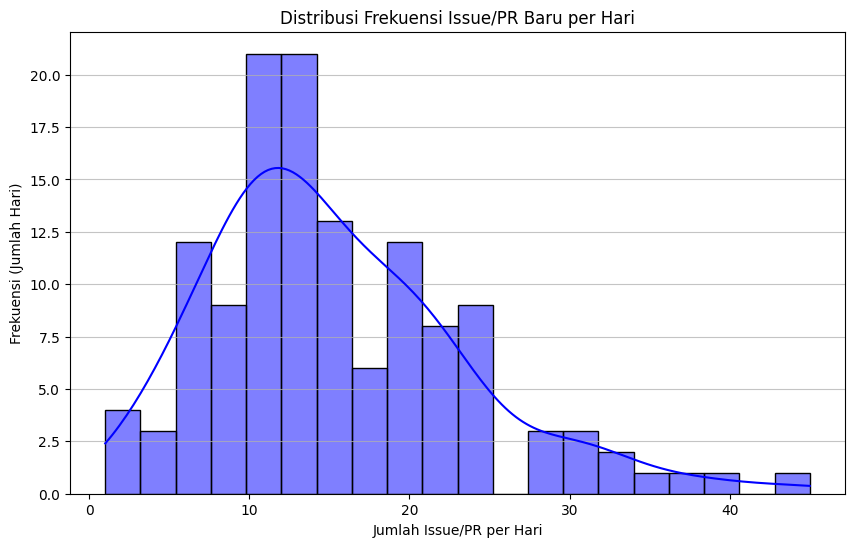

In [12]:
# Ekstrak tanggal (tanpa jam) untuk menghitung frekuensi harian
df['date_only'] = df['created_at'].dt.date
daily_counts = df.groupby('date_only').size()

plt.figure(figsize=(10, 6))
sns.histplot(daily_counts, bins=20, kde=True, color='blue')
plt.title('Distribusi Frekuensi Issue/PR Baru per Hari')
plt.xlabel('Jumlah Issue/PR per Hari')
plt.ylabel('Frekuensi (Jumlah Hari)')
plt.grid(axis='y', alpha=0.75)
plt.show()

**Interpretasi Grafik Poisson:**
[Dari grafik di atas, dapat dilihat bahwa repository ini paling sering menerima sekitar 10–12 issue/PR per hari (puncak histogram berada di rentang tersebut). Distribusi menceng ke kanan (right skewed), di mana sebagian besar hari memiliki aktivitas rendah-sedang, namun ada beberapa hari dengan lonjakan hingga 40+ issue/PR per hari. Kurva garis biru yang terbentuk menyerupai bentuk distribusi Poisson tidak simetris, dan memiliki ekor panjang ke kanan. Ini merupakan karakteristik khas dari data hitungan kejadian acak per satuan waktu. Oleh karena itu, data ini cocok dimodelkan menggunakan distribusi Poisson dengan parameter λ (lambda) ≈ rata-rata jumlah issue/PR per hari, yang dapat dihitung oleh Member B menggunakan Poisson MLE: λ̂ = 15.38.]

In [ ]:
lambda_hat = np.mean(daily_counts)
print(f"λ̂ = {lambda_hat:.2f}")

λ̂ = 15.38


### 4. Visualisasi untuk Distribusi Bernoulli (Status Pull Request)
Melihat rasio keberhasilan Pull Request (Merged) dibandingkan yang ditolak (Closed without Merge). Data ini biner (1/0) dan akan diolah menggunakan Maximum Likelihood Estimation (MLE) Bernoulli.

C:\Users\zaida\AppData\Local\Temp\ipykernel_37552\812403108.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pr_status_counts.index, y=pr_status_counts.values, palette='Set2')


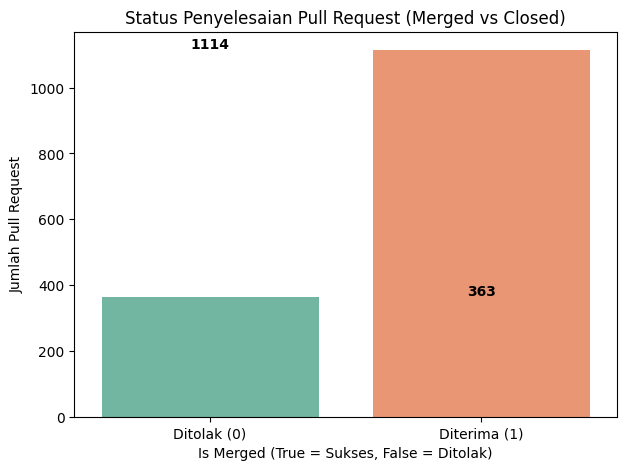

In [14]:
# Filter hanya data Pull Request yang sudah selesai (closed)
pr_df = df[(df['is_pull_request'] == True) & (df['state'] == 'closed')]

# Hitung jumlah merged vs ditolak
pr_status_counts = pr_df['is_merged'].value_counts()

plt.figure(figsize=(7, 5))
sns.barplot(x=pr_status_counts.index, y=pr_status_counts.values, palette='Set2')
plt.title('Status Penyelesaian Pull Request (Merged vs Closed)')
plt.xlabel('Is Merged (True = Sukses, False = Ditolak)')
plt.ylabel('Jumlah Pull Request')
plt.xticks(ticks=[0, 1], labels=['Ditolak (0)', 'Diterima (1)'])

# Tambahkan label angka di atas bar
for i, v in enumerate(pr_status_counts.values):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.show()

**Interpretasi Grafik Bernoulli:**
[menurut bar chart di atas, dari total 1.477 Pull Request yang sudah ditutup (363 + 1114), terdapat 1.114 PR yang berhasil di-merge (diterima) dan 363 PR yang ditolak. Artinya, sekitar 75,4% PR berhasil diterima oleh maintainer repo ini. Terdapat ketimpangan yang jelas antara PR yang diterima dan ditolak, di mana PR yang diterima hampir 3x lebih banyak dibanding PR yang ditolak. Hal ini mengindikasikan bahwa repo ini cukup aktif menerima kontribusi dari luar. Karena setiap PR hanya memiliki dua kemungkinan hasil diterima dan ditolak, data ini cocok dimodelkan menggunakan distribusi Bernoulli dengan parameter p̂ = 1114 / 1477 ≈ 0.754. Nilai p̂ ini selanjutnya akan diestimasi secara formal oleh Member B menggunakan Bernoulli MLE: p̂ = k/n.
k = 1114 (jumlah sukses)
n = 1477 (total obeservasi)]

### Kesimpulan Handoff
Tahap Exploratory Data Analysis selesai. Data `dataset.csv` sudah bersih dari duplikasi, memiliki format waktu yang benar, dan variabel penentu seperti `is_merged` dan `author_association` telah terekstrak dengan baik. Data ini diserahkan kepada **Ihsan (Member B)** untuk dilakukan kalkulasi fungsi MLE dan Beta Posterior.